In [1]:
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP, SparseCMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

2026-05-06 11:43:33.492747: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 11:43:33.569004: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-06 11:43:33.700019: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-06 11:43:33.701004: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 11:43:34.662153: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def standardize(s, mu=None, std=None):
    if not mu and not std:
        return (s - np.nanmean(s)) / np.nanstd(s)
    else:
        return (s - mu) / std

if not os.path.isfile("volatility_data.npz"):
    amzn = yf.download('AMZN', start='2021-01-01', end='2024-01-01')
    vix = yf.download('^VIX', start='2021-01-01', end='2024-12-01')
    amzn_test = yf.download('AMZN', start='2024-01-01', end='2024-06-01')

    amzn_monthly = amzn['Close'].resample('M').last()
    vix_weekly = vix['Close'].resample('D').last().interpolate("cubicspline")
    amzn_monthly_test = amzn_test['Close'].resample('M').last()

    amzn_monthly_returns = np.nan_to_num(amzn_monthly.values, 0)
    amzn_monthly_test_returns = np.nan_to_num(amzn_monthly_test.values, 0)
    vix_weekly_vals = vix_weekly.values

    Bx = amzn_monthly.index.view("int64").reshape(-1, 1).astype(float)
    Xtest = amzn_monthly_test.index.view("int64").reshape(-1, 1).astype(float)
    Ax = vix_weekly.index.view("int64").reshape(-1, 1).astype(float)
    Xtest = (Xtest - Bx.min()) /(Bx.max() - Bx.min())
    Ax = (Ax - Bx.min()) /(Bx.max() - Bx.min())
    Bx = (Bx - Bx.min()) /(Bx.max() - Bx.min())
    By = standardize(amzn_monthly_returns).reshape(-1, 1)
    Ay = standardize(vix_weekly_vals).reshape(-1, 1)
    ytest = standardize(amzn_monthly_test_returns, mu=np.nanmean(amzn_monthly_returns), std=np.nanstd(amzn_monthly_returns)).reshape(-1, 1)

    X = np.vstack((np.hstack((Ax, np.zeros_like(Ax))), np.hstack((Bx, np.ones_like(Bx)))))
    y = np.vstack((np.hstack((Ay, np.zeros_like(Ay))), np.hstack((By, np.ones_like(By)))))
    Xtest = np.hstack((Xtest, np.ones_like(Xtest)))

    np.savez(file="volatility_data.npz", X=X, y=y, Xtest=Xtest, ytest=ytest)

    print(len(Ax), len(Ay), len(Bx), len(By))
    print(Bx, By)
else:
    data = np.load("volatility_data.npz")
    X = data["X"]
    y = data["y"]
    Xtest = data["Xtest"]
    ytest = data["ytest"]
    Ax = X[X[:,1] == 0]
    Bx = X[X[:,1] == 1] 
    Ay = y[y[:,1] == 0]
    By = y[y[:,1] == 1]
    print(len(Ax) ,len(Bx))

/tmp/ipykernel_607/2235253783.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn = yf.download('AMZN', start='2021-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_607/2235253783.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download('^VIX', start='2021-01-01', end='2024-12-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_607/2235253783.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn_test = yf.download('AMZN', start='2024-01-01', end='2024-06-01')
[*********************100%***********************]  1 of 1 completed

1426 1426 36 36
[[0.        ]
 [0.02631579]
 [0.05545113]
 [0.08364662]
 [0.11278195]
 [0.14097744]
 [0.17011278]
 [0.19924812]
 [0.22744361]
 [0.25657895]
 [0.28477444]
 [0.31390977]
 [0.34304511]
 [0.3693609 ]
 [0.39849624]
 [0.42669173]
 [0.45582707]
 [0.48402256]
 [0.51315789]
 [0.54229323]
 [0.57048872]
 [0.59962406]
 [0.62781955]
 [0.65695489]
 [0.68609023]
 [0.71240602]
 [0.74154135]
 [0.76973684]
 [0.79887218]
 [0.82706767]
 [0.85620301]
 [0.88533835]
 [0.91353383]
 [0.94266917]
 [0.97086466]
 [1.        ]] [[ 0.85840675]
 [ 0.64460601]
 [ 0.64677649]
 [ 1.35146819]
 [ 0.89024965]
 [ 1.3000138 ]
 [ 1.08753447]
 [ 1.35782928]
 [ 1.00721987]
 [ 1.1721716 ]
 [ 1.42630879]
 [ 1.10027509]
 [ 0.45309703]
 [ 0.60370333]
 [ 0.95986163]
 [-0.50169245]
 [-0.65541306]
 [-1.18390346]
 [-0.09894981]
 [-0.40775015]
 [-0.9275765 ]
 [-1.32622329]
 [-1.5489522 ]
 [-2.02234541]
 [-1.30017554]
 [-1.63615611]
 [-1.2941353 ]
 [-1.21259404]
 [-0.64142649]
 [-0.27222516]
 [-0.1468933 ]
 [ 0.0165671 ]


/tmp/ipykernel_607/2235253783.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  amzn_monthly = amzn['Close'].resample('M').last()
/tmp/ipykernel_607/2235253783.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  amzn_monthly_test = amzn_test['Close'].resample('M').last()


In [3]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    plt.plot(Ax, Ay, "x", color="C0", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, "C0", "Y1")

    plt.plot(Bx, By, "x",color="C1", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, "C1", "Y2")
    try:
        ivs = m.inducing_variable.Z.numpy() 
        plt.scatter(ivs, np.zeros_like(ivs)+2, marker="|", c=m.inducing_indices, cmap="PiYG")
        plt.colorbar()
    except AttributeError:
        pass
    plt.xlim([0, max(X[:,0])])
    plt.legend()
    return mu


def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()
 

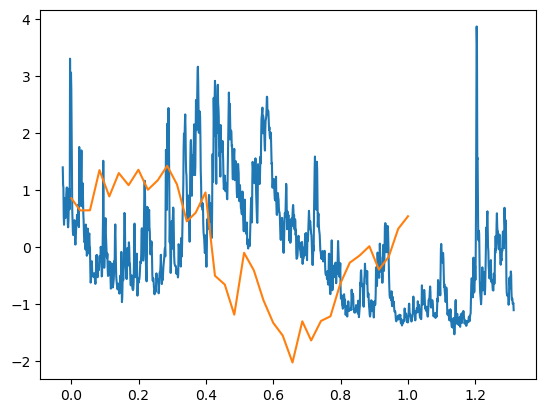

In [4]:
plt.plot(Ax, Ay)
plt.plot(Bx, By)

In [5]:
output_dim = 2  # Number of outputs
rank = 2  # Rank of W

# Base kernel
k = gpf.kernels.Matern12(active_dims=[0])
k2 = gpf.kernels.Matern32(active_dims=[0])
# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
coreg2 = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
ivs = np.linspace(0, max(X[:,0]), 20).reshape(-1, 1)
iv_ind = np.ones((int(len(ivs)),1))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg + k2 * coreg2  # <- how the fuck does this work then
m = SparseCMOGP((X, y), exact_target=True, kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
# gpf.set_trainable(m.inducing_variable.Z, False)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

TypeError: SparseCMOGP.__init__() got an unexpected keyword argument 'exact_target'

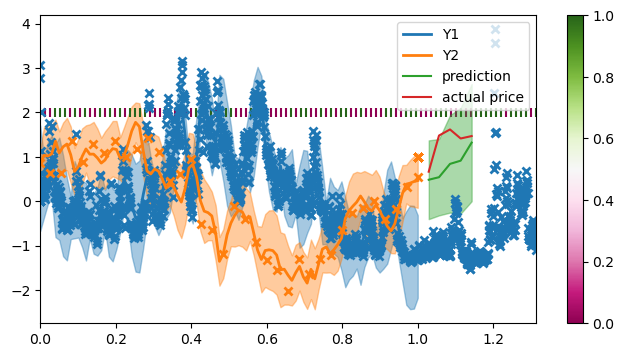

0.35697872166010225


In [ ]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu, label="prediction", color="C2")
plt.plot(Xtest[:,0], ytest, label="actual price", color="C3")

plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))


In [ ]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
k = gpf.kernels.Matern12(active_dims=[0])
k2 = gpf.kernels.Matern32(active_dims=[0])
# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
coreg2 = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
ivs = np.linspace(0, max(X[:,0]), 100).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg + k2 * coreg2  # <- how the fuck does this work then

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-05-06 11:30:15.786772: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-05-06 11:30:15.870524: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 1015.3896232298533
        x: [-1.134e-01  2.578e-01 ... -1.557e+00 -9.995e-01]
      nit: 2964
      jac: [-8.708e+00 -7.604e+00 ...  4.788e+00  8.252e-01]
     nfev: 3487
     njev: 3487
 hess_inv: <5368x5368 LbfgsInvHessProduct with dtype=float64>

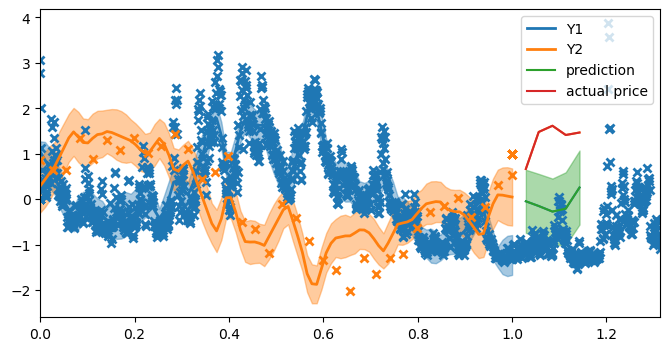

2.162349191908409


In [ ]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu)
plt.plot(Xtest[:,0], ytest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))